In [19]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [20]:
df = pd.read_csv('NFCE_OUT24_A_DEZ24_8708.csv', sep = ';', encoding = 'latin1')
df = df.rename(columns = {i:i.lower() for i in list(df.columns)})

In [21]:
print(f'Quantidade de linhas de df: {df.shape[0]}.')
print(f'Quantidade de descrições únicas de produtos em df: {len(set(df.xprod))}.')
print(f'Quantidade de unidades comerciais únicas em df: {len(set(df.ucom))}.')
print(f'Quantida de CNAE únicas: {len(set(df.cnae_principal))}.')
print(f'Quantidade de segmentos únicos: {len(set(df.segmento))}.')

Quantidade de linhas de df: 3560680.
Quantidade de descrições únicas de produtos em df: 1179952.
Quantidade de unidades comerciais únicas em df: 502.
Quantida de CNAE únicas: 191.
Quantidade de segmentos únicos: 16.


# Sorteando uma amostra de tamanho 50 mil:

In [22]:
random_state = 1234

df = df.sample(n = 50000, random_state = random_state)
df = df.reset_index(drop = True)

In [23]:
df.head().to_csv('cabecalho.csv')

# Análise:

In [24]:
print(f'Quantidade de linhas de df: {df.shape[0]}.')
print(f'Quantidade de descrições únicas de produtos em df: {len(set(df.xprod))}.')
print(f'Quantidade de unidades comerciais únicas em df: {len(set(df.ucom))}.')
print(f'Quantida de CNAE únicas: {len(set(df.cnae_principal))}.')
print(f'Quantidade de segmentos únicos: {len(set(df.segmento))}.')

Quantidade de linhas de df: 50000.
Quantidade de descrições únicas de produtos em df: 40512.
Quantidade de unidades comerciais únicas em df: 111.
Quantida de CNAE únicas: 106.
Quantidade de segmentos únicos: 15.


## Analisando a variável ucom:

In [25]:
# A variável ucom é qualitativa em formato de texto.
# Apesar de haver 100 unidades de medida diferentes, muitas delas poderiam ser reunidas na mesma definição.

# Por exemplo, "PC", provavelmente se refere a uma PEÇA. Uma peça é uma unidade (unida é escrita, na maioria das vezes,
# como "UN"). Além de haver "PC", há "PC.", "PCA" e assim por diante. Todas essas peças poderiam ser reunidas em "UN" ou "UNID".

# Ou seja, não existe uma padronização para esta variável.
# Em combinação com xProd, pode haver redundância. Por exemplo, xProd = "KIT REPARO ALAVANCA CAMBIO -10499-2/20.438" e ucom = "KIT".
# Outra unidade de medida que não é informativa é "¿PC".

# Opta-se por não realizar um pré-processamento nesta variável, tampouco utilizá-la na modelagem por aprendizado não supervisionado,
# já que é inviável padronizá-la, devido a ucom não informativas como "J3", "KI", "159852" etc, impossibilitando a sua padronização.

print(list(set(df.ucom)))

['BS', 'KIT', '36', 'BD', 'PT', 'MM', '257727', 'ST', '1', 'J4', 'IND', 'P38', 'JG.', '0', 'UND8', 'RL', 'TB', 'PECA', 'EA', 'CT', 'TUB', 'LT.', 'SC', 'CM', 'GALAO', 'PC', 'UN.', 'UNIDA', 'UNIDAD', 'PCS', 'H1', 'AP', 'UN1', '4C', '37', 'KT2', 'MT', 'JO', 'PÃ', 'LATA', 'PCA', 'CJ', '6', 'UN', '00', 'JGO8', 'UNITA', 'AR', '35', 'JOG', 'UND9', 'UND', 'CD', 'LI', 'LITRO', 'JC', 'MT.', 'UM', 'PC0', 'JG', '1000UN', 'FD', 'PAR', '12', 'PA', 'GL', 'BL', 'P', 'METRO', 'PÇ', 'KG', '2', '28', 'UNID', 'BAR', 'KM', 'M', '21', 'PEC', 'L', 'KT', 'PB', 'UD', 'PC.', '01', 'JOGO', 'RP', 'PECA (', 'PE', '5', '20', 'UNS', 'FR', 'KL', 'PCT', 'UNI', 'LT', 'LIT', 'SV', 'REP', 'CX', 'ML', '16', 'KU', 'JGO', 'IUN', 'CE', 'U', 'UNT', 'PR', 'KI']


## Analisando a variável qcom:

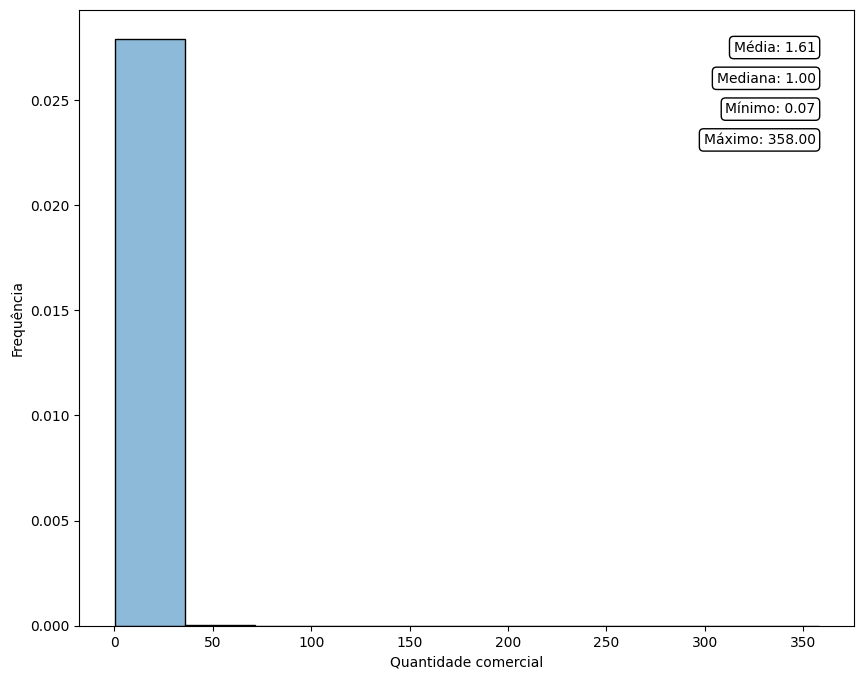

In [26]:
# A variável qcom é quantitativa contínua.

# Variável despadronizada e totalmente ligada a xProd e a ucom. Pela sua despadronização, que pode
# trazer desinformação ao aprendizado não supervisionado, opta-se por não utilizar essa variável.

# Abaixo são demonstrados exemplom da confusão gerada pela combinação de xProd, ucom e qcom:

# xProd = "SERVICO", ucom = "UN" e qcom = "3,7071". O que significa 3,7071 de um serviço?
# xProd = "HG33020-AMORTECEDOR DIANT FIAT", ucom = "PAR", qcom = "0.5". O que foi comercializado foi claramente
# um amortecedor, mas a quantidade comercial (qcom) indica que foi meio amortecedor (1/2 = 0,5).

media = df.qcom.mean()
mediana = df.qcom.median()
minimo = df.qcom.min()
maximo = df.qcom.max()
plt.figure(figsize = (10, 8))
sns.histplot(data = df, x = 'qcom', bins = 10, alpha = 0.5, stat = 'density')
#plt.title('Histograma da quantidade comercial de produtos comercializados')
plt.xlabel('Quantidade comercial')
plt.ylabel('Frequência')
plt.text(
    0.95, 0.95,
    f'Média: {media:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.9,
    f'Mediana: {mediana:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.85,
    f'Mínimo: {minimo:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.8,
    f'Máximo: {maximo:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.show();

## Retirando linhas duplicadas:

In [27]:
# O ideal é retirar as linhas duplicadas para realizar a clusterização.

df_unicos = df.drop_duplicates(subset = ['xprod', 'vuncom'])
print(f'Quantidade de linhas duplicadas em df: {df.shape[0]-df_unicos.shape[0]}. Essa quantidade de produto foi comercializada com a mesma unidade de medida,\
 mesma quantidade comercial, mesmo valor unitário de comercialização, pelo mesmo ou outro contribuinte com o mesmo CNAE e que participa do mesmo segmento.')
print(f'Quantidade de linhas de df_unicos: {df_unicos.shape[0]}.')
print(f'Quantidade de descrições únicas de produtos em df_unicos: {len(set(df_unicos.xprod))}.')
print(f'Quantidade de unidades comerciais únicas em df_unicos: {len(set(df_unicos.ucom))}.')

Quantidade de linhas duplicadas em df: 2350. Essa quantidade de produto foi comercializada com a mesma unidade de medida, mesma quantidade comercial, mesmo valor unitário de comercialização, pelo mesmo ou outro contribuinte com o mesmo CNAE e que participa do mesmo segmento.
Quantidade de linhas de df_unicos: 47650.
Quantidade de descrições únicas de produtos em df_unicos: 40512.
Quantidade de unidades comerciais únicas em df_unicos: 111.


## Analisando a variável xProd:

In [28]:
# Trata-se de uma variável qualitativa, em forma de texto.
# Conforme o MOC, versão 7.0, a descrição do produto ou do serviço é um campo de livre preenchimento pelo contribuinte emissor do documento fiscal,
# tendo um tamanho de até 120 caracteres.
# Analisando a quantidade de caracteres por descrição, observa-se que algumas possuem apenas uma letra ou um número.
# São campos totalmente não informativos. O ideal seria retirá-los do banco de dados.

dc = {i:len(i) for i in list(df_unicos.xprod)}
print(sorted(list(dc.items()), key = lambda x: x[1])[:10])
print(20 * '-----')
df_unicos[df_unicos.xprod == '0'].head()

[('0', 1), ('X', 1), ('9', 1), ('KIT', 3), ('TBI', 3), ('RODA', 4), ('PIVO', 4), ('TUBO', 4), ('EIXO', 4), ('CABO', 4)]
----------------------------------------------------------------------------------------------------


,xprod,ucom,qcom,vuncom,ncm,cest,cnae_principal,segmento
4893,0,UN,1.0,100.0,87082999,107500.0,COMÉRCIO A VAREJO DE PEÇAS E ACESSÓRIOS NOVOS ...,AUTOMOTORES


C:\Users\filipe.figueira\AppData\Local\Temp\1\ipykernel_3908\3218224353.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unicos['qtd_caracteres'] = [len(i) for i in list(df_unicos.xprod)]


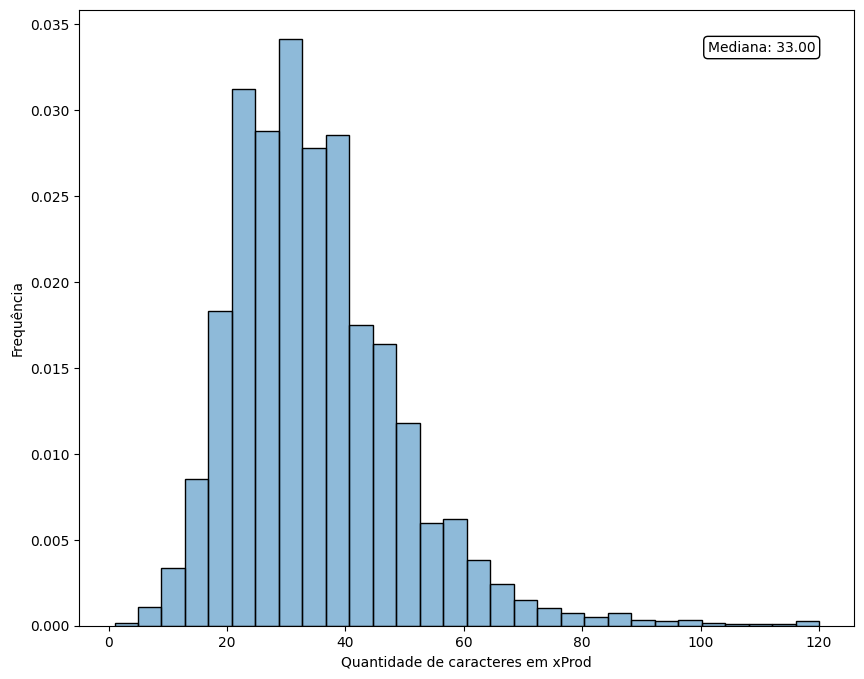

In [29]:
# Analisando a quantidade de caracteres por descrição do produto ou serviço, observa-se que possui uma distribuição assimétrica à direita, 
# com mediana igual a 33, ou seja, 50% das descrições possuem menos de 33 caracteres.

df_unicos['qtd_caracteres'] = [len(i) for i in list(df_unicos.xprod)]
mediana = df_unicos.drop_duplicates(subset = 'xprod').qtd_caracteres.median()
plt.figure(figsize = (10, 8))
sns.histplot(data = df_unicos.drop_duplicates(subset = 'xprod'), x = 'qtd_caracteres', bins = 30, alpha = 0.5, stat = 'density')
#plt.title('Histograma da quantidade de caracteres em xProd')
plt.xlabel('Quantidade de caracteres em xProd')
plt.ylabel('Frequência')
plt.text(
    0.95, 0.95,
    f'Mediana: {mediana:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.show();

In [30]:
# Contando a quantidade de descrições que possuem 5 ou menos caracteres. Deve-se analisar o quanto são informativas as descrições
# com essa quantidade de caracteres.

df_unicos.groupby('qtd_caracteres').size().reset_index(name = 'qtd_descricoes').sort_values(by = 'qtd_caracteres').head(5)

,qtd_caracteres,qtd_descricoes
0,1,3
1,3,2
2,4,69
3,5,69
4,6,54


In [31]:
# Descrições com 1 caractere não são informativas. Devem ser retirados do banco de dados.

print(list(set(df_unicos[df_unicos.qtd_caracteres == 1].xprod)))

['9', '0', 'X']


In [32]:
# Descrições com 3 caractere podem ser informativas. Deve ser feita uma análise para saber se devem ser retiradas do banco de dados.
# Descrições como "KIT" tendem a ser não informativas, pois parece um kit genérico.

print(list(set(df_unicos[df_unicos.qtd_caracteres == 3].xprod)))

['TBI', 'KIT']


In [33]:
# Descrições com 4 caractere podem ser informativas, pois palavras começam a ser formadas.

print(list(set(df_unicos[df_unicos.qtd_caracteres == 4].xprod)))

['CABO', 'SUCO', 'CAPA', 'RACK', 'ALMA', 'VELA', 'AGUA', 'PINO', 'LUVA', 'RODA', 'EIXO', 'BICO', 'PIVO', 'CAPO', 'ANEL', 'SELO', 'TUBO']


In [34]:
# Retirando descrições com tamanho 1, 2 ou 3 de df_unicos:

df_unicos = df_unicos[df_unicos.qtd_caracteres > 4]
print(f'Quantidade de linhas de df_unicos: {df_unicos.shape[0]}.')
print(f'Quantidade de descrições únicas de produtos em df_unicos: {len(set(df_unicos.xprod))}.')
print(f'Quantidade de unidades comerciais únicas em df_unicos: {len(set(df_unicos.ucom))}.')

Quantidade de linhas de df_unicos: 47576.
Quantidade de descrições únicas de produtos em df_unicos: 40490.
Quantidade de unidades comerciais únicas em df_unicos: 111.


## Analisando a variável vuncom:

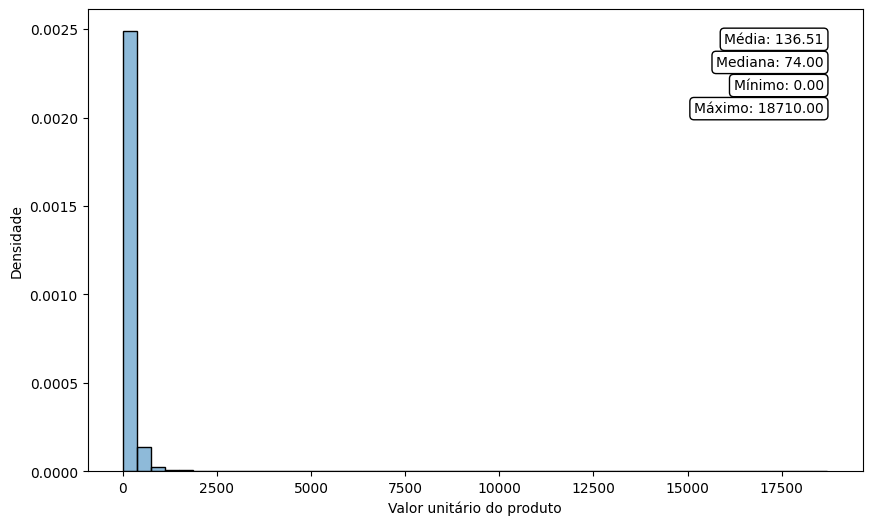

In [35]:
# A variável vuncom é quantitativa contínua.

# A distribuição da variável vuncom é extremamente assimétrica à direita e concentrada em baixos valores.

# Observa-se a presença de 2 produtos em que vuncom é igual a 0, ou seja, foram comercializadas com valor zerado.

media = df_unicos.vuncom.mean()
mediana = df_unicos.vuncom.median()
minimo = df_unicos.vuncom.min()
maximo = df_unicos.vuncom.max()
plt.figure(figsize = (10, 6))
sns.histplot(data = df_unicos, x = 'vuncom', bins = 50, alpha = 0.5, stat = 'density')
#plt.title('Histograma do valor unitário do produto')
plt.xlabel('Valor unitário do produto')
plt.ylabel('Densidade')
plt.text(
    0.95, 0.95,
    f'Média: {media:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.9,
    f'Mediana: {mediana:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.85,
    f'Mínimo: {minimo:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.8,
    f'Máximo: {maximo:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.savefig('vuncom_8708.png', dpi = 300, format = 'png')
plt.show();

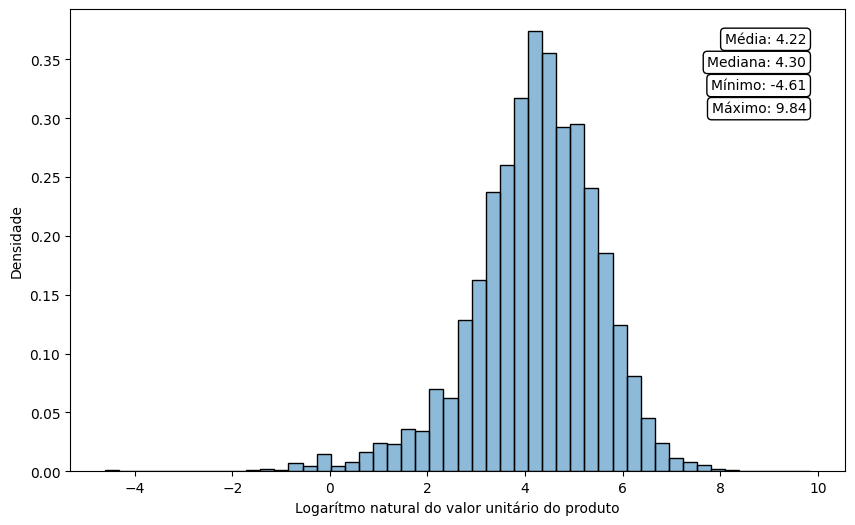

In [36]:
# Opta-se por transformar a variável para diminuir a sua variabilidade.
# Transformando o valor unitário do produto, considerando a transformação igual a log(x + 1), evitando valores
# infinitos quando x = 0, encontra-se uma distribuição simétrica em torno de sua média.

# Será mantida a variável "log_vuncom" no modelo de clusterização.

df_unicos = df_unicos[df_unicos.vuncom != 0]
df_unicos['log_vuncom'] = np.log(df_unicos.vuncom)
media = df_unicos.log_vuncom.mean()
mediana = df_unicos.log_vuncom.median()
minimo = df_unicos.log_vuncom.min()
maximo = df_unicos.log_vuncom.max()
plt.figure(figsize = (10, 6))
sns.histplot(data = df_unicos, x = 'log_vuncom', bins = 50, alpha = 0.5, stat = 'density')
#plt.title('Histograma do logarítmo natural do valor unitário do produto')
plt.xlabel('Logarítmo natural do valor unitário do produto')
plt.ylabel('Densidade')
plt.text(
    0.95, 0.95,
    f'Média: {media:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.9,
    f'Mediana: {mediana:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.85,
    f'Mínimo: {minimo:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.text(
    0.95, 0.8,
    f'Máximo: {maximo:.2f}',
    ha = 'right', va = 'top',
    transform = plt.gca().transAxes,
    bbox = dict(boxstyle = 'round', facecolor = 'white', edgecolor = 'black')
)
plt.savefig('log_vuncom_8708.png', dpi = 300, format = 'png')
plt.show();

# Pré-processamento da variável xProd:

In [37]:
# Serão propostos 4 tipos de pré-processamento para a variável xProd, sendo cada pré-processamento uma etapa a mais do processamento anterior.

# 1º pré-processamento: xProd minúsculo;
# 2º pré-processamento: 1º pré-processamento sem acentos;
# 3º pré-processamento: 2º pré-processamento somente com caracteres alfanuméricos, sem caracteres especiais;
# 4º pré-processamento: 3º pré-processamento sem números;

## 1º pré-processamento:

In [38]:
def remover_acentos(texto):
    if pd.isnull(texto):
        return texto
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return texto.lower()

In [39]:
df_unicos['T1'] = df_unicos['xprod'].str.lower()

## 2º pré-processamento:

In [40]:
# 2º pré-processamento: 1º pré-processamento sem acentos;

df_unicos['T2'] = df_unicos['T1'].apply(remover_acentos)

## 3º pré-processamento:

In [41]:
# 3º pré-processamento: 2º pré-processamento somente com caracteres alfanuméricos, sem caracteres especiais;

df_unicos['T3'] = df_unicos['T2'].apply(lambda x: re.sub(r'[^a-z0-9\s]', ' ', x) if pd.notnull(x) else x)

## 4º pré-processamento:

In [42]:
# 4º pré-processamento: 3º pré-processamento sem números;

df_unicos['T4'] = df_unicos['T3'].apply(
    lambda x: re.sub(r'\s+', ' ', re.sub(r'\d+', ' ', x)).strip() if pd.notnull(x) else x
)

# Salvando o banco de dados em dados_pre_processados.csv:

In [43]:
df_unicos.reset_index(drop=True, inplace=True)
df_unicos['idx'] = df_unicos.index

In [44]:
df_unicos.to_csv('dados_pre_processados_8708.csv')